# 日経平均株価 と 楽天２２５ダブルベア (1459) の相関

In [1]:
import sys

path_up = ".."
if not path_up in sys.path:
    sys.path.append(path_up)

In [2]:
import datetime
import os

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn import preprocessing

In [3]:
code1 = "^N225"
yticker1 = yf.Ticker(code1)
code2 = "1459.T"
yticker2 = yf.Ticker(code2)

In [16]:
df1 = yticker1.history(period="3y", interval="1d")
df2 = yticker2.history(period="3y", interval="1d")

In [17]:
ss = preprocessing.StandardScaler()

df = pd.DataFrame(
    {
        code1: df1["Close"],
        code2: df2["Close"],
    }
)
df.corr()

,^N225,1459.T
^N225,1.000000,-0.890588
1459.T,-0.890588,1.000000


In [18]:
df

,^N225,1459.T
Date,,
2023-03-06 00:00:00+09:00,28237.779297,1322.0
2023-03-07 00:00:00+09:00,28309.160156,1315.0
2023-03-08 00:00:00+09:00,28444.189453,1307.0
2023-03-09 00:00:00+09:00,28623.150391,1288.0
2023-03-10 00:00:00+09:00,28143.970703,1331.0
...,...,...
2026-02-27 00:00:00+09:00,58850.269531,168.0
2026-03-02 00:00:00+09:00,58057.238281,172.0
2026-03-03 00:00:00+09:00,56279.050781,184.0


In [19]:
datascope = f"datascope: {df.index[0].date()} - {df.index[-1].date()}, n={len(df):,.0f}"

In [20]:
dt = df.index[-1]
path_target = os.path.join(f"{dt.year:04d}", f"{dt.month:02d}",  f"{dt.day:02d}")

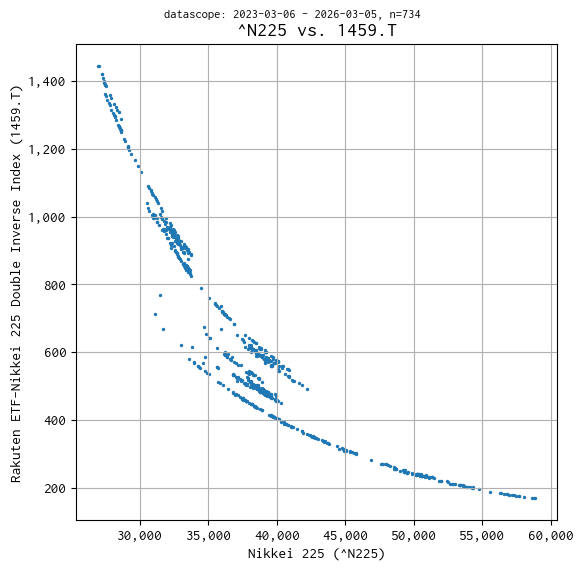

In [21]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 12

fig, ax = plt.subplots(figsize=(6, 5.8))
ax.scatter(df[code1], df[code2], s=2)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax.tick_params(axis='both', which='major', labelsize=11)

ax.grid()

ax.set_title(f"{code1} vs. {code2}")
ax.set_xlabel(f"{yticker1.info['longName']} ({code1})", fontsize=11)
ax.set_ylabel(f"{yticker2.info['longName']} ({code2})", fontsize=11)
plt.suptitle(datascope, fontsize=9)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig(os.path.join(path_target, "n255_vs_1459.png"))
plt.show()